# Obtain and Load Data


---
Problem: Predict "Median House Value" based on the relationship between other independent variables (features).


In [62]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np


In [63]:
# dataset loaded by using url
url = 'https://raw.githubusercontent.com/LinkedInLearning/artificial-intelligence-foundations-machine-learning-3067770/main/housing.csv'


# read in the data with read_csv() into a Pandas Dataframe
housing_df = pd.read_csv(url)


In [64]:
# dataset loaded by import the dataset as a file (csv)
# read in the data with read_csv() into a Pandas Dataframe

housing_df = pd.read_csv('housing.csv')

# use info to show the features in your dataset along with a count and datatype
housing_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# Use visualization to understand the relationship of the target variable with other features (variables).


---

**1.  Histograms**

Text(0, 0.5, 'Frequency - Number of Houses')

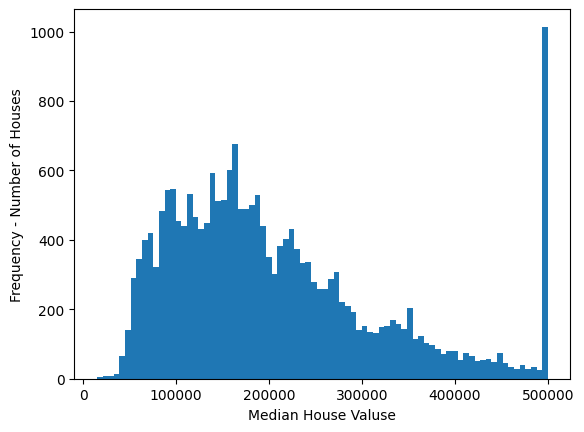

In [65]:
# Plot the distribution of target variable (Median House Value) using a histrogram.

# bins -> Amount of columns / Number of bars in the histogram

plt.hist(housing_df['median_house_value'], bins=80)
plt.xlabel('Median House Valuse')
plt.ylabel('Frequency - Number of Houses')


```
Output - Text(0, 0.5, 'Frequency - Number of Houses')
```

It means;
*   Text → a text object was created
*   0 → x-position of the label
*   0.5 → y-position of the label
*   'Frequency' → the actual text displayed

---


🔹 Can hide it using;
```
plt.ylabel('Frequency');
```
or
```
plt.show()
```





**More bins → more detailed view**

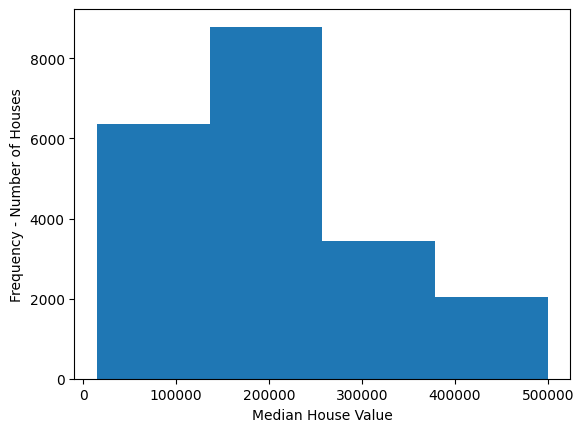

In [66]:
plt.hist(housing_df['median_house_value'], bins=4)
plt.xlabel('Median House Value')
plt.ylabel('Frequency - Number of Houses');

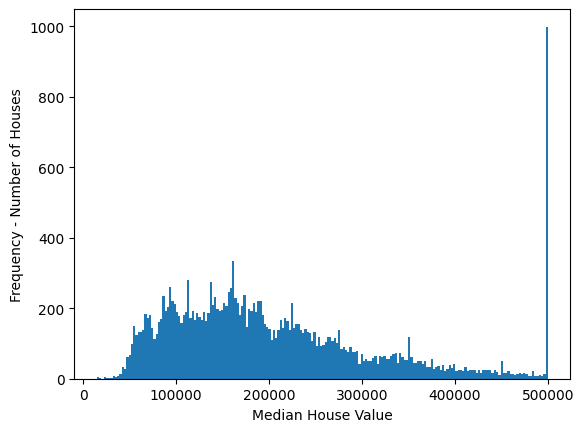

In [67]:
plt.hist(housing_df['median_house_value'], bins=200)
plt.xlabel('Median House Value')
plt.ylabel('Frequency - Number of Houses')

plt.show()


**Observation**

*   Most of the houses around range 100,000 - 200,000
*   We can see the valuse of 'Median House Value' distributed normally with fewer outliers.



**Histrograms for all other features to understand the data distributions.**

🔹 Since 'ocean_proximity' is non-numeric, a histrogram is not needed.

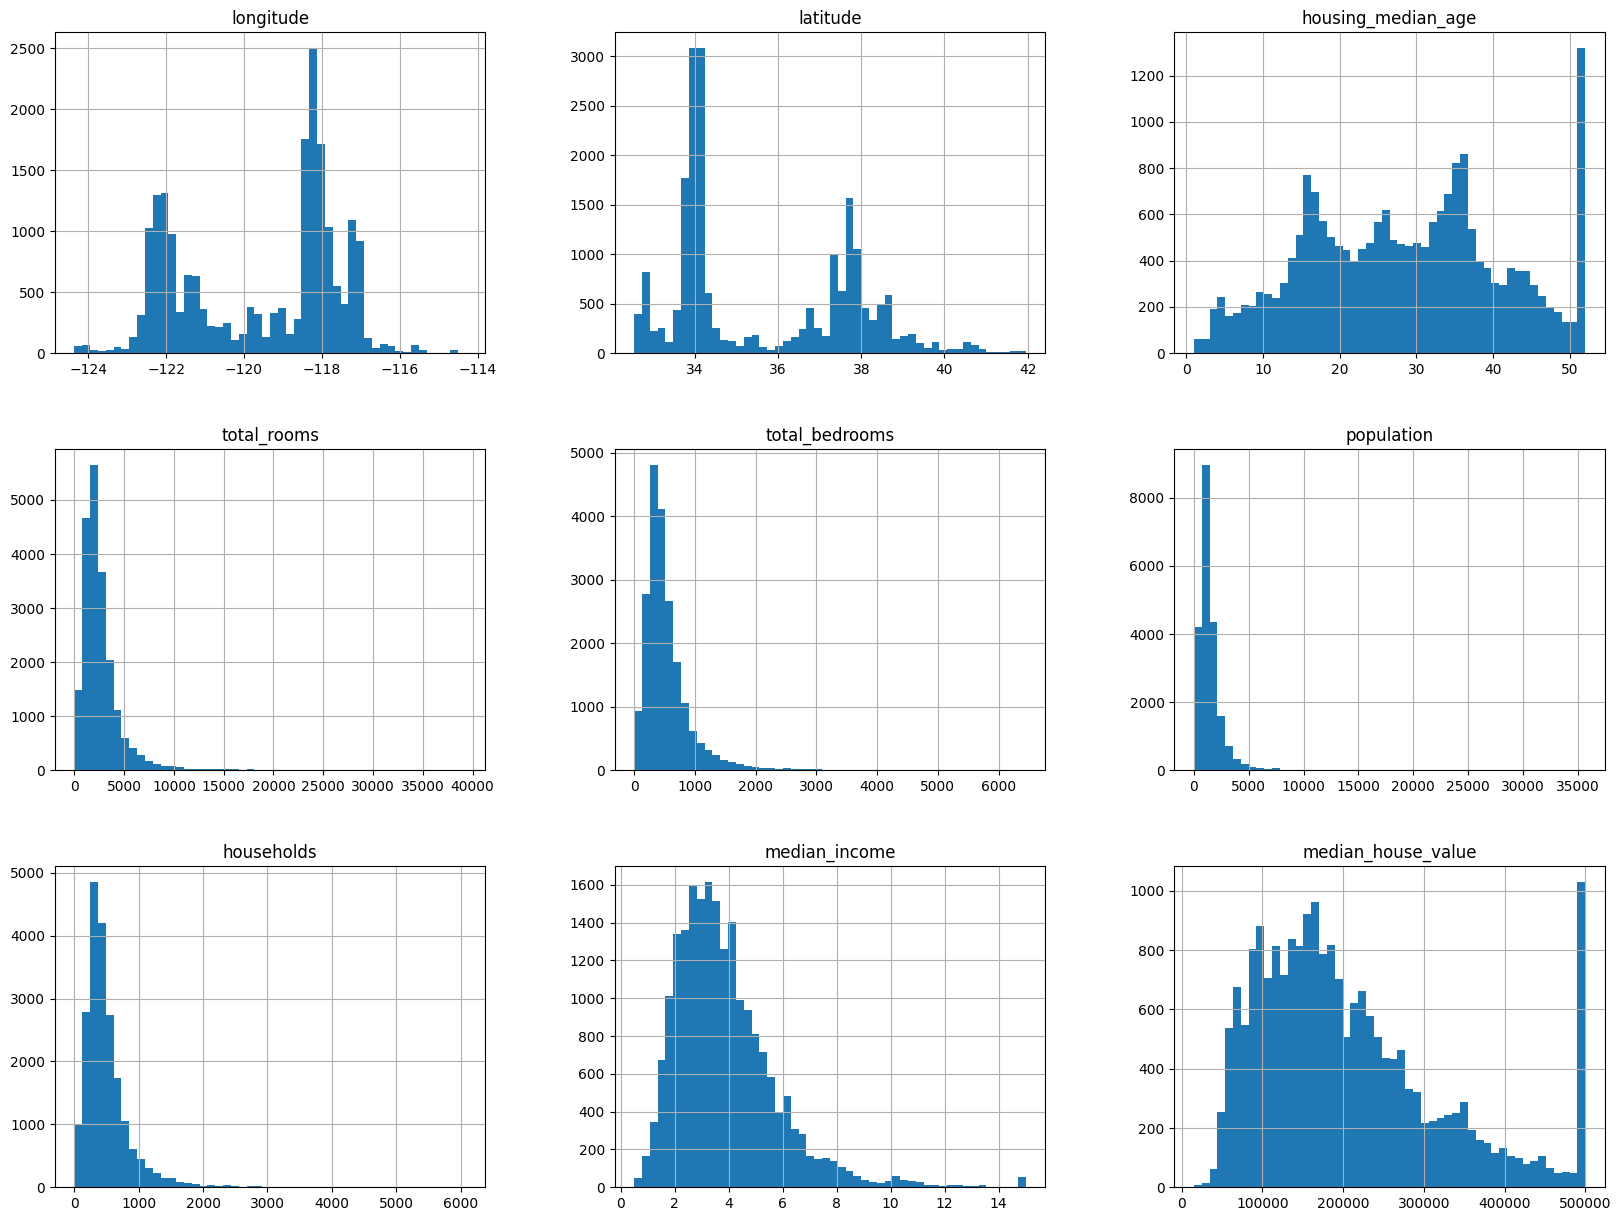

In [68]:
housing_df.hist(bins=50, figsize=(20,15));

# plt.show()

**Observation**

*   There are outliers for "housing_median_age" & "median_house_value"
*   Because there are odd peak values as its maximum value.



---





**2. Heat Maps**

Show the correlation between features or how one feature is related to another feature.

*   **If features are highly ocrrelated** -> Those features could possible teach the model the same thing.
*   **Duplicated features should be removed** to speed up the training process, save money & improve the model prediction capability.



---


🔹 READING THE HEATMAP

*   Except the line from top left to bottom right (All take 1): Other cells expect to values FROM 0 TO 1.
*   **Value closure to 0 ** -> Shows low correlation
*   **Values closure to 1** -> Shows high correlation





*   **.corr()** -> calculates correlation
*   Correlation only works on numerical values.
*   'ocean_proximity' feature is not a numeric value'
*   So use -> corr = housing_df.corr(**numeric_only=True**)



In [69]:
corr = housing_df.corr(numeric_only=True)

#convert output with 5 decimal points
corr.round(5)

#print(corr.round(5))

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00000,-0.92466,-0.10820,0.04457,0.06961,0.09977,0.05531,-0.01518,-0.04597
latitude,-0.92466,1.00000,0.01117,-0.03610,-0.06698,-0.10878,-0.07104,-0.07981,-0.14416
housing_median_age,-0.10820,0.01117,1.00000,-0.36126,-0.32045,-0.29624,-0.30292,-0.11903,0.10562
total_rooms,0.04457,-0.03610,-0.36126,1.00000,0.93038,0.85713,0.91848,0.19805,0.13415
total_bedrooms,0.06961,-0.06698,-0.32045,0.93038,1.00000,0.87775,0.97973,-0.00772,0.04969
population,0.09977,-0.10878,-0.29624,0.85713,0.87775,1.00000,0.90722,0.00483,-0.02465
households,0.05531,-0.07104,-0.30292,0.91848,0.97973,0.90722,1.00000,0.01303,0.06584
median_income,-0.01518,-0.07981,-0.11903,0.19805,-0.00772,0.00483,0.01303,1.00000,0.68808
median_house_value,-0.04597,-0.14416,0.10562,0.13415,0.04969,-0.02465,0.06584,0.68808,1.00000


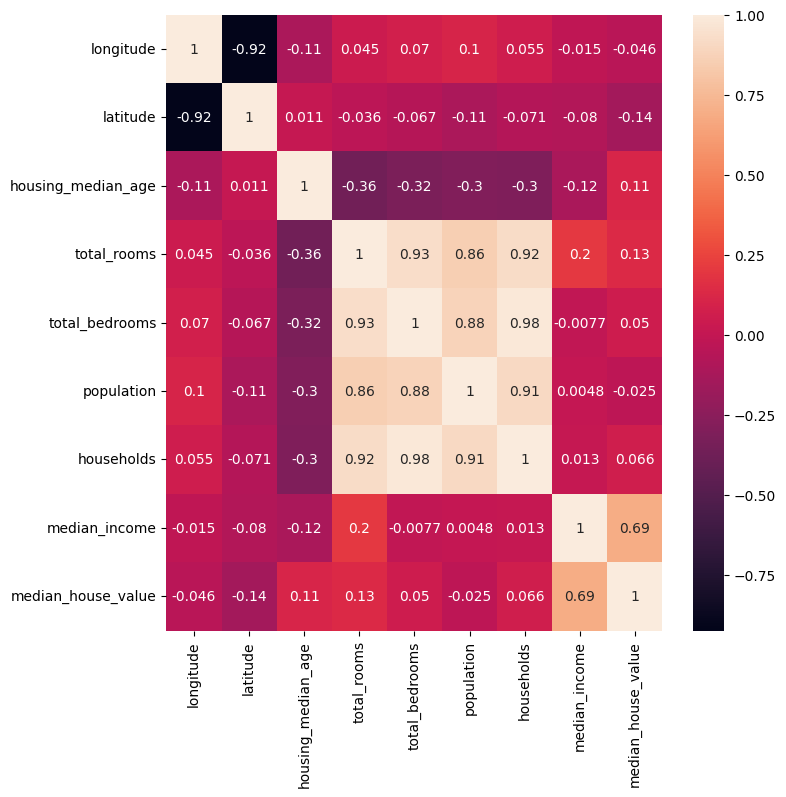

In [70]:
#Make a heatmap larger in size.

plt.figure(figsize=(8,8))

sns.heatmap(corr, annot=True);



*   If light pink appears more than once in a row; consider those features are correlted.

> **Example:** total_rooms, total_bedrooms, population and households are highly correlated features. So they are candidates for removal.



# Feature Engineering

---

**A process of manipulating data by;**
*   Adding new features
*   Removing highly correlated or duplicated features
*   Combining features (highly correlated features)
*   Creating new features



🔹For feature engineering requires fully understanding of the data and the relationship between features.

In [71]:
# Above scenario we already identify total_rooms, total_bedrooms, population and households are highly correlated features.
# Strategy - Create a relatively simple combination of the correlated features and drop the rest.

# 1. A new feature -> rooms_per_household.
housing_df['rooms_per_household'] = housing_df['total_rooms']/housing_df['households']

# 2. A new feature -> bedrooms_per_room.
housing_df['bedrooms_per_room'] = housing_df['total_bedrooms']/housing_df['total_rooms']

# 3. A new feature -> population_per_household.
housing_df['population_per_household'] = housing_df['population']/ housing_df['households']

# Create a new feature by combining the longitude and latitude (because there's a negative correlation)
housing_df['coords'] = housing_df['longitude']+housing_df['latitude']

housing_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20433 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  object 
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20433 non-null  float64
 12  population_per_household  20640 non-null  float64
 13  coords                    20640 non-null  float64
dtypes: flo

In [72]:
# After created the above new fetures, then remove the original correlated features

housing_df = housing_df.drop(['total_rooms','total_bedrooms','population','households','longitude','latitude'], axis = 1)

# Also can seperately delete each feature like -> housing_df = housing_df.drop('total_rooms', axis = 1)

housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   housing_median_age        20640 non-null  float64
 1   median_income             20640 non-null  float64
 2   median_house_value        20640 non-null  float64
 3   ocean_proximity           20640 non-null  object 
 4   rooms_per_household       20640 non-null  float64
 5   bedrooms_per_room         20433 non-null  float64
 6   population_per_household  20640 non-null  float64
 7   coords                    20640 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.3+ MB


**New heat map after removing correlation**

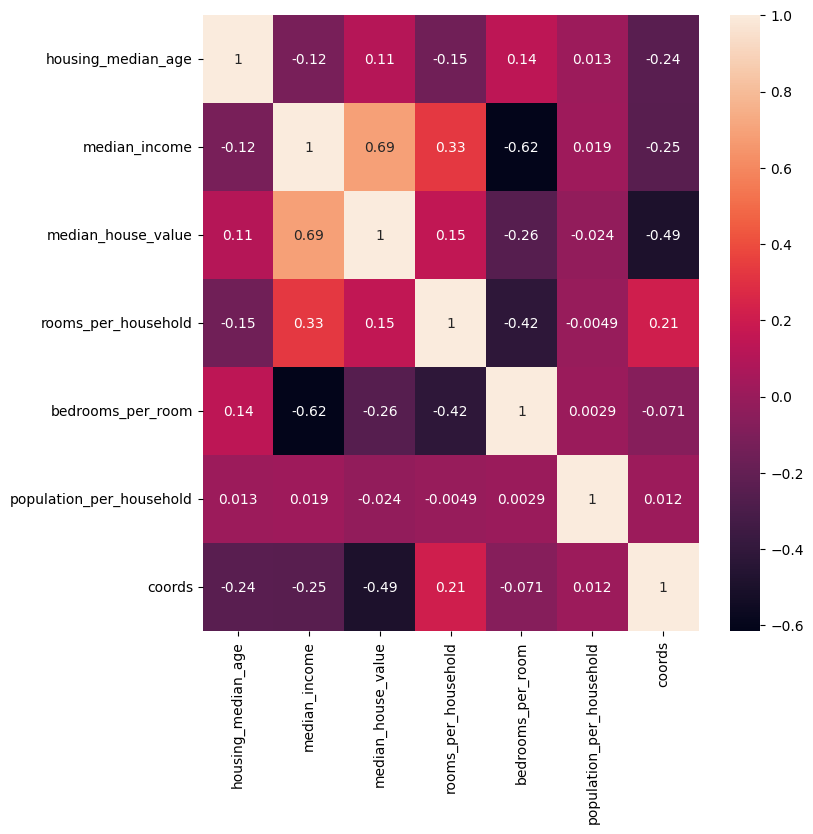

In [73]:
corr = housing_df.corr(numeric_only=True)

#convert output with 5 decimal points
corr.round(5)

#make the heatmap larger in size
plt.figure(figsize=(8,8))

sns.heatmap(corr, annot=True)
plt.show()

🔹 In this new heat map, high correlations no longer exsist.

**Encode Categorical Data**

Most ML algorithms learn from numeric data. Therefore categorical data must be encoded. (or convert into numeric data.)


🔹 Encoding Technique Used - **One Hot Encoding**

🔹 After encoding can remove the original columns (features)

🔹 One-hot encoding can cause *HIGH CARDINALITY* -> means increased features results in dimentionality

> (This is not good since when # of features increase it's harder to models to learn, reduce generalize and increased training cost.)



In [80]:
# One Hot Encoding

# Use panda's get_dummies() function

ocean_encoded = pd.get_dummies(housing_df['ocean_proximity'], dtype=int)
ocean_encoded

# can write this in sigle line -> print(pd.get_dummies(housing_df['ocean_proximity'])) ; output get in TRUE/False format


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
20635,0,1,0,0,0
20636,0,1,0,0,0
20637,0,1,0,0,0
20638,0,1,0,0,0


In [82]:
# Replace 'ocean_proximity' column in the dataset using get_dummies() function
housing_df_encoded = pd.get_dummies(housing_df, columns = ['ocean_proximity'])

# print the first few observations
# NOTE: ocean_proximity column is gone now.

housing_df_encoded.head()


,housing_median_age,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,coords,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,8.3252,452600.0,6.984127,0.146591,2.555556,-84.35,False,False,False,True,False
1,21.0,8.3014,358500.0,6.238137,0.155797,2.109842,-84.36,False,False,False,True,False
2,52.0,7.2574,352100.0,8.288136,0.129516,2.802260,-84.39,False,False,False,True,False
3,52.0,5.6431,341300.0,5.817352,0.184458,2.547945,-84.40,False,False,False,True,False
4,52.0,3.8462,342200.0,6.281853,0.172096,2.181467,-84.40,False,False,False,True,False


**Ways to handle missing values**
1. Remove missing values (Applicable if it not effect the size of the dataset and # of missing data are very few.)
2. Mean / Median Imputation - Replace missing value with mean or average score of the rest of the data. (Applicable only for numeric values)
3. Mode imputation (Applicable for ctegorical values) OR encode
4. Imputate missing data using ML


In [75]:
# Verify which feature has missing values
housing_df.isnull().sum()

,0
housing_median_age,0
median_income,0
median_house_value,0
ocean_proximity,0
rooms_per_household,0
bedrooms_per_room,207
population_per_household,0
coords,0


In [78]:
# there are 207 missing values in total_betrooms feature
# This might be incorrect because every home should have at least one bedroom.
# So need to handle these missing values appropriately.
